In [12]:
import pandas as pd
import numpy as np
import sklearn
from scipy.io import arff

from sklearn import datasets
from sklearn import tree
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import itertools

from matplotlib.colors import LinearSegmentedColormap

from sklearn.utils import Bunch

In [13]:
import sklearn

print(
    "The scikit-learn version is {}.".format(sklearn.__version__)
)  # check your scikit learn version, the latest version is 0.21.3

The scikit-learn version is 1.6.1.


In [14]:
# Q1: Load HW6.csv file
data = pd.read_csv("HW6.csv")

In [15]:
num_sample, num_feature = data.shape
np.unique(data["target"])
num_label = len(np.unique(data["target"]))
print("we have %i samples in total" % num_sample)
print("we have %i features in total" % num_feature)
print("we have %i labels in total" % num_label)

we have 257 samples in total
we have 6 features in total
we have 4 labels in total


In [16]:
le = preprocessing.LabelEncoder()
for i in range(data.shape[1]):
    if data.dtypes[i] == "object":
        data.iloc[:, i] = le.fit_transform(data.iloc[:, i])

# Create dataBunch
dataBunch = Bunch(
    data=data.iloc[:, 0:5].values,
    target=data.iloc[:, 5].values,
    feature_names=np.array(data.columns[:5]),
    target_names=np.unique(data.iloc[:, 5]),
)

# Train/test split
train_x, test_x, train_y, test_y = train_test_split(
    dataBunch.data, dataBunch.target, test_size=0.2, random_state=0
)

/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/1041404181.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data.dtypes[i] == "object":
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/1041404181.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data.dtypes[i] == "object":
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/1041404181.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.ilo

In [ ]:
# Define a function to plot the decision boundary, return the fitted tree model
def decision_boundary(
    inputData, x, y, plot_step=0.02, plot_colors="rybg", n_classes=4, method="gini"
):
    # Need to input x and y
    # Default plot step is 0.02
    # Default number of classes is 4
    # Default color is red yellow blue green. Four labels, each of label corresponds to a color
    # Default method is gini, one can also use entropy
    plt.figure(figsize=(12, 10))  # Define the size of the figure
    for index, pair in enumerate(list(itertools.combinations(list(range(5)), 2))):

        # Q3: Get a pair of X
        X = x[:, pair]
        Y = y
        Y = Y.astype(int)

        # print("X shape is %s" % str(X.shape))
        # print("Y shape is %s" % str(Y.shape))
        # print("Y dtype is %s" % str(Y.dtype))
        # print("First 10 rows of Y is %s" % str(Y[:10]))
        # print("Unique labels in Y is %s" % str(np.unique(Y)))

        # Q4: train tree
        clf = tree.DecisionTreeClassifier(criterion=method).fit(X, Y)

        # Plot the decision boundary
        plt.subplot(2, 5, index + 1)  # 2 rows, 3 columns

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, (x_max - x_min) / 40),
            np.arange(y_min, y_max, (y_max - y_min) / 40),
        )
        plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

        # Q4: predict for values on meshgrid by the model trained before
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        colors = [(1, 0, 0), (1, 1, 0), (0, 0, 1), (0, 1, 0)]

        n_bins = 10

        cmap_name = "my_list"

        cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

        cs = plt.contourf(xx, yy, Z, cmap=cm)

        plt.xlabel(inputData.feature_names[pair[0]])
        plt.ylabel(inputData.feature_names[pair[1]])

        for i, color in zip(range(n_classes), plot_colors):
            idx = np.where(Y == i)
            plt.scatter(
                X[idx, 0],
                X[idx, 1],
                c=color,
                label=inputData.target_names[i],
                cmap=plt.cm.RdYlBu,
                edgecolor="black",
                s=15,
            )

    plt.suptitle("Decision surface of a decision tree using paired features")
    plt.legend(loc="lower right", borderpad=0, handletextpad=0)
    plt.axis("tight")

    return clf

X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


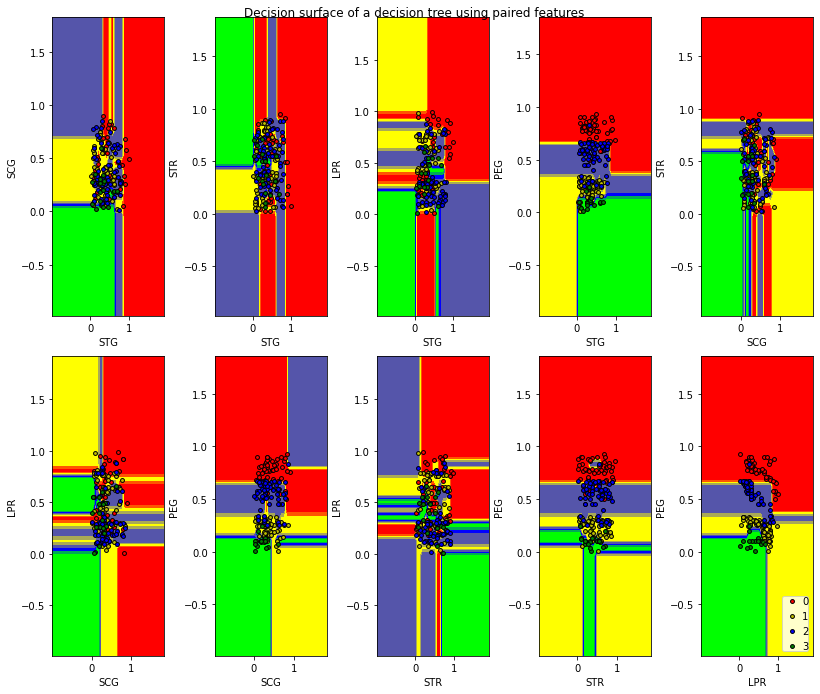

In [22]:
model = decision_boundary(dataBunch, train_x, train_y)

X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


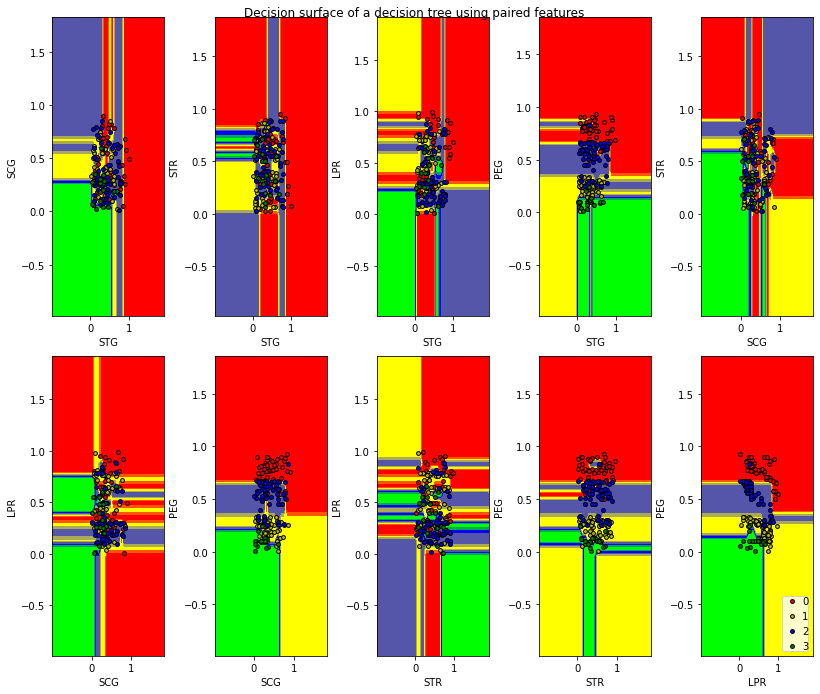

In [23]:
# Q5: use "decision_boundary" defined before. Use entropy as method. Pay attention to inputs
model = decision_boundary(dataBunch, train_x, train_y, method="entropy")

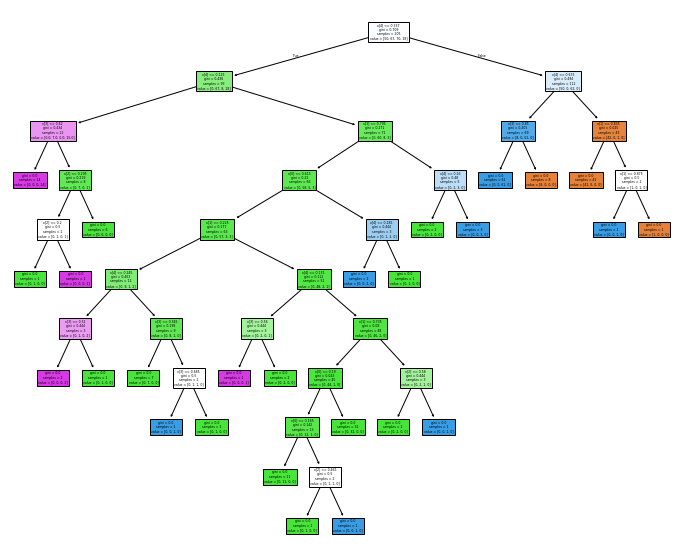

In [25]:
plt.figure(figsize=(12, 10))
train_y = train_y.astype(int)
clf = tree.DecisionTreeClassifier().fit(train_x, train_y)
tree.plot_tree(clf, filled=True)
plt.show()

X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/

X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)
Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]
X shape is (205, 2)
Y shape is (205,)


/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/var/folders/g6/gz_6b6590yq5mjnxkmqvn8340000gp/T/ipykernel_76452/376440815.py:57: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Y dtype is int64
First 10 rows of Y is [1 1 1 1 0 2 0 3 1 3]
Unique labels in Y is [0 1 2 3]


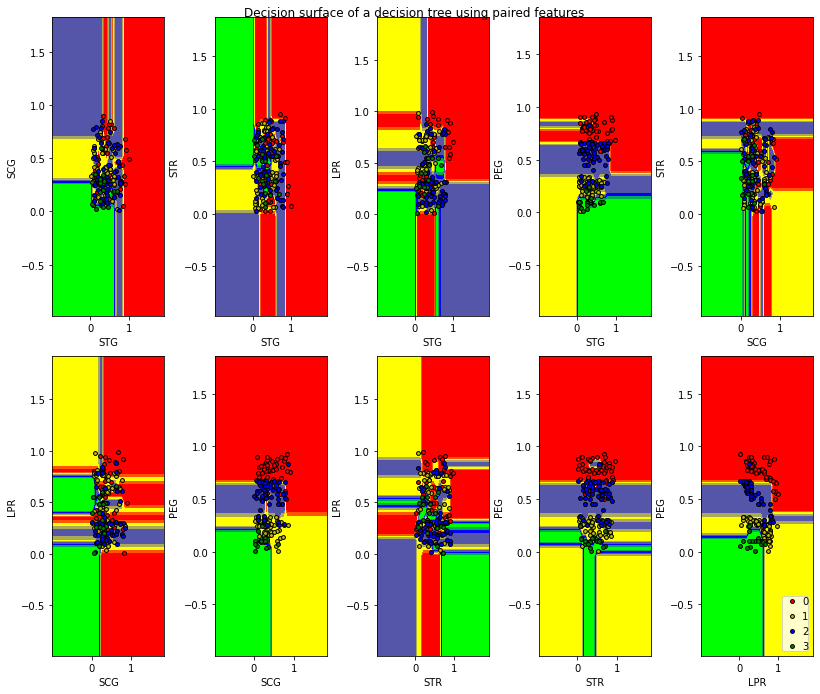

In [26]:
# Q6: use "decision_boundary" defined before. Use gini as method. Pay attention to inputs.
model = decision_boundary(dataBunch, train_x, train_y, method="gini")

In [28]:
tree_model = tree.DecisionTreeClassifier().fit(train_x, train_y)  # Tree training
test_y = test_y.astype(int)
print(
    "The proportion of the points that are correctly classified is %f"
    % metrics.accuracy_score(test_y, tree_model.predict(test_x))
)

The proportion of the points that are correctly classified is 0.865385


In [29]:
print("The depth of the tree is %i" % tree_model.get_depth())

The depth of the tree is 10


In [30]:
# Q7: print accuracy for depths of 1 to 10
for depth in range(1, 11):
    tree_model = tree.DecisionTreeClassifier(max_depth=depth).fit(train_x, train_y)
    print(
        "The proportion of the points that are correctly classified is %f"
        % metrics.accuracy_score(test_y, tree_model.predict(test_x))
    )

The proportion of the points that are correctly classified is 0.576923
The proportion of the points that are correctly classified is 0.846154
The proportion of the points that are correctly classified is 0.903846
The proportion of the points that are correctly classified is 0.865385
The proportion of the points that are correctly classified is 0.884615
The proportion of the points that are correctly classified is 0.884615
The proportion of the points that are correctly classified is 0.884615
The proportion of the points that are correctly classified is 0.865385
The proportion of the points that are correctly classified is 0.865385
The proportion of the points that are correctly classified is 0.846154
